#### Supp. Fig 3a, b, Fig 1e

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import seaborn as sns  
import pandas as pd  
import random
import statsmodels.api as sm
pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title

})

save_dir = "boxplot_normalized_to_total_cell_abundance_ann_finest_level"
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

boxprops=dict(edgecolor="black")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='black')



In [3]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/h5ad/adata_vis_assigned_cell_types_ann_finest_level.h5ad")


In [4]:
adata_vis

AnnData object with n_obs × n_vars = 160702 × 16959
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'alignment', 'desired_rc', 'actual_rc', 'xmin', 'xmax', 'ymin', 'ymax', 'hpx', 'vpx', 'slide', 'area', 'date', 'cytassist_ver', 'seq_batch', 'probe_date', 'probe_lot', 'probe_group', 'cond', 'cond_rep', 'rep', 'age ', 'sex', 'bmi', 'packyears', 'FVC', 'DLCO', '6MWD', 'outcome_long', 'tte_long', 'outcome_24m', 'tte_24m', 'lobe_lr', 'lobe', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'training_batch', 'AT0', 'AT1', 'AT2', 'AT2 proliferating', 'Adventitial fibroblasts', 'Alveolar Mph CCL3+', 'Alveolar Mph M

In [5]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266,0.010062,0.009213,0.056085,0.024774,0.080588,0.040189,0.030853,0.005049,0.038562,0.017642,0.068411,0.598156,0.124178,0.036192,0.026985,0.061592,0.055564,0.479931,0.034395,0.011473,0.129968,0.007446,0.244876,0.049037,0.007688,0.022190,0.089888,0.012039,0.379554,EC aerocyte capillary
AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2120,7.659643,3313.0,8.105911,26.048898,30.878358,37.488681,51.101720,538.0,6.289716,16.239059,0.0,0.0,0.0,0.0,0.0,0.0,3313.0,2120,0,0.005170,0.059832,0.082329,0.001831,0.001260,0.013375,0.011541,0.018772,0.068402,0.020841,0.011103,0.004326,0.079482,0.039857,0.005894,0.012759,0.000413,0.376290,0.007926,0.002451,1.006702,0.058915,2.460315,0.390035,0.384114,0.002900,0.001124,0.012576,0.005301,0.008660,0.003291,0.010103,0.009291,0.070889,0.000651

In [6]:
adata_vis.obs[adata_vis.uns['mod_0']['factor_names']] = adata_vis.obsm['q05_cell_abundance_w_sf']
adata_vis.obs[adata_vis.uns['mod_1']['factor_names']] = adata_vis.obsm['q05_cell_abundance_w_sf']

In [7]:
adata_vis.uns

{'mod_0': {'date': '2025-07-12',
  'factor_filter': array([], dtype=float64),
  'factor_names': array(['AT0', 'AT1', 'AT2', 'AT2 proliferating',
         'Adventitial fibroblasts', 'Alveolar Mph CCL3+',
         'Alveolar Mph MT-positive', 'Alveolar Mph proliferating',
         'Alveolar fibroblasts', 'Alveolar macrophages', 'B cells',
         'Basal resting', 'CD4 T cells', 'CD8 T cells',
         'Classical monocytes', 'Club (nasal)', 'Club (non-nasal)', 'DC1',
         'DC2', 'Deuterosomal', 'EC aerocyte capillary', 'EC arterial',
         'EC general capillary', 'EC venous pulmonary',
         'EC venous systemic', 'Goblet (bronchial)', 'Goblet (nasal)',
         'Goblet (subsegmental)', 'Hillock-like',
         'Interstitial Mph perivascular', 'Ionocyte',
         'Lymphatic EC differentiating', 'Lymphatic EC mature',
         'Mast cells', 'Mesothelium', 'Migratory DCs',
         'Monocyte-derived Mph', 'Multiciliated (nasal)',
         'Multiciliated (non-nasal)', 'Myofibroblas

In [8]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266,0.010062,0.009213,0.056085,0.024774,0.080588,0.040189,0.030853,0.005049,0.038562,0.017642,0.068411,0.598156,0.124178,0.036192,0.026985,0.061592,0.055564,0.479931,0.034395,0.011473,0.129968,0.007446,0.244876,0.049037,0.007688,0.022190,0.089888,0.012039,0.379554,EC aerocyte capillary
AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2120,7.659643,3313.0,8.105911,26.048898,30.878358,37.488681,51.101720,538.0,6.289716,16.239059,0.0,0.0,0.0,0.0,0.0,0.0,3313.0,2120,0,0.005170,0.059832,0.082329,0.001831,0.001260,0.013375,0.011541,0.018772,0.068402,0.020841,0.011103,0.004326,0.079482,0.039857,0.005894,0.012759,0.000413,0.376290,0.007926,0.002451,1.006702,0.058915,2.460315,0.390035,0.384114,0.002900,0.001124,0.012576,0.005301,0.008660,0.003291,0.010103,0.009291,0.070889,0.000651

In [9]:
adata_vis.obsm["q05_cell_abundance_w_sf"]

array([[9.66656720e-04, 8.13243969e-05, 2.29026300e-05, ...,
        4.45834920e-02, 1.35436561e-03, 3.23585438e-04],
       [1.37827709e-01, 8.02714944e-01, 3.41799647e-01, ...,
        8.98878872e-02, 1.20390868e-02, 3.79554302e-01],
       [5.16986102e-03, 5.98323643e-02, 8.23287666e-02, ...,
        2.13461649e-02, 2.78973859e-03, 4.72171174e-04],
       ...,
       [2.77333297e-02, 4.14859265e-01, 9.10561383e-01, ...,
        1.32177249e-01, 2.53166985e-02, 9.94704384e-03],
       [7.24286661e-02, 4.49035585e-01, 2.43868160e+00, ...,
        4.33246233e-02, 1.65227652e-02, 2.33426578e-02],
       [7.94081926e-01, 4.58053684e+00, 8.70211720e-01, ...,
        1.07862167e-01, 7.27577042e-03, 3.48671083e-03]])

In [10]:
adata_vis.uns['mod'] = adata_vis.uns['mod_0']

In [11]:
df = sc.get.obs_df(adata_vis, keys = list(adata_vis.obs.columns)).reset_index()

In [12]:
ct = np.unique(adata_vis.obs["cell_type_assigned"].tolist())

In [13]:
ct

array(['AT0', 'AT1', 'AT2', 'AT2 proliferating',
       'Adventitial fibroblasts', 'Alveolar Mph CCL3+',
       'Alveolar Mph MT-positive', 'Alveolar Mph proliferating',
       'Alveolar fibroblasts', 'Alveolar macrophages', 'B cells',
       'Basal resting', 'CD4 T cells', 'CD8 T cells',
       'Classical monocytes', 'Club (nasal)', 'Club (non-nasal)', 'DC1',
       'DC2', 'Deuterosomal', 'EC aerocyte capillary', 'EC arterial',
       'EC general capillary', 'EC venous pulmonary',
       'EC venous systemic', 'Goblet (bronchial)', 'Goblet (nasal)',
       'Goblet (subsegmental)', 'Hillock-like',
       'Interstitial Mph perivascular', 'Ionocyte',
       'Lymphatic EC differentiating', 'Lymphatic EC mature',
       'Mast cells', 'Mesothelium', 'Migratory DCs',
       'Monocyte-derived Mph', 'Multiciliated (nasal)',
       'Multiciliated (non-nasal)', 'Myofibroblasts', 'NK cells',
       'Neuroendocrine', 'Non-classical monocytes',
       'Peribronchial fibroblasts', 'Pericytes', 'Plasm

In [14]:
filter_cts_list = ['AT2 proliferating','Alveolar Mph MT-positive','Alveolar Mph proliferating',
                   'Basal resting','Classical monocytes','Club (nasal)', 'Club (non-nasal)', 'DC1',
       'DC2', 'Deuterosomal','Goblet (bronchial)', 'Goblet (nasal)',
       'Goblet (subsegmental)', 'Hillock-like','Ionocyte','Mesothelium', 'Migratory DCs',
        'Multiciliated (nasal)','Neuroendocrine', 'Non-classical monocytes','Plasmacytoid DCs', 'SM activated stress response', 'SMG duct', 'Unknown', 'Suprabasal']

In [15]:
cts_nmf_filtered = [ct for ct in ct if ct not in filter_cts_list]

In [16]:
df.groupby("library_id")[['cond','rep']].head(5)

,cond,rep
0,IPF,1
1,IPF,1
2,IPF,1
3,IPF,1
4,IPF,1
...,...,...
157825,IPF,10
157826,IPF,10
157827,IPF,10
157828,IPF,10


In [17]:
df.groupby("library_id")[ct].sum()

,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,pre-TB secretory
library_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
06_30914_A1,357.914260,2496.250136,3320.016631,246.933095,226.867416,972.096854,139.148471,203.945413,1259.485075,1546.927992,723.152950,78.452703,1430.519927,1199.337768,218.818392,144.936802,43.623302,568.854130,274.790500,23.411700,1324.370510,255.737460,1091.699545,154.686410,206.484553,58.024974,58.079752,71.046342,59.977088,1027.541973,116.819769,287.893141,93.297510,159.439686,105.875162,821.915963,1921.611412,120.895744,43.442275,245.683126,1269.349034,169.207276,602.848398,137.576555,613.625306,1428.854235,245.747044,44.530962,150.855866,268.983686,63.219111,226.932527,67.817564,1021.780745,158.706401
08_38774_B2,145.111351,630.728626,952.765800,153.492873,321.032290,46.423768,39.399312,65.171500,1878.467323,268.641897,275.921191,76.549831,362.890187,200.608607,71.534024,243.764432,22.600905,70.369753,60.369386,84.573302,364.657122,228.483856,344.510925,246.639578,510.463311,33.584777,35.357460,73.357396,79.708167,277.684247,106.821058,774.278652,285.315962,202.175696,154.597649,126.223771,53.976576,263.239352,178.449049,377.594061,181.961269,227.367022,80.995485,404.084153,324.799665,317.184844,98.718749,294.841171,293.085436,1265.515417,457.819743,253.186094,74.074701,181.765250,103.580829
11_13888_A1,518.582199,6086.238280,5507.407013,311.927465,648.694752,363.391550,124.645530,189.574007,2518.814529,1840.920449,284.518033,118.213702,631.078534,521.092506,204.027068,94.410032,52.537804,207.793993,234.895900,43.378458,2923.587638,592.871725,2645.991660,258.129811,304.299455,62.874555,59.928065,90.153260,83.280256,291.797683,182.243336,669.990993,237.921172,324.162923,379.265078,211.270553,188.078412,74.745000,150.040114,545.251197,512.701614,227.784903,278.438717,326.307762,1385.459081,587.123572,154.974101,132.907948,86.941711,457.045768,146.802468,82.918948,103.000604,322.569136,121.630210
12_39986_A2,402.518568,2143.358220,3912.002067,559.688570,214.280170,172.949172,133.450165,181.695846,1912.361563,729.071167,949.830582,170.372188,914.975198,467.894453,184.544360,359.475818,89.320397,125.123101,153.098106,73.484270,1129.685375,317.925686,1081.040654,197.060637,564.672799,80.733060,75.687107,162.011894,328.154027,461.285063,173.424408,563.742377,240.313597,274.248993,148.961741,367.531712,271.195307,309.437249,151.552771,240.573280,416.319540,293.635174,253.695630,919.359594,841.981970,3645.984837,302.652722,179.069608,328.993105,492.260434,118.318598,499.406030,283.208504,461.209191,231.461310
16_39724_B1,692.295613,3622.384937,5558.321352,188.312707,672.690564,505.926615,67.241937,148.690582,2360.491592,911.308487,147.702592,158.282848,451.110081,377.738443,277.801382,23.676162,32.818055,196.134333,256.490017,8.653915,1236.480230,326.219909,1279.881548,270.095192,545.979691,20.961254,41.344602,26.683372,53.062022,993.463277,100.473153,233.773550,265.328483,192.123796,105.404750,114.212371,1137.946275,15.597505,75.185407,558.601984,285.728340,144.451237,227.540009,276.157468,956.170930,306.518525,75.812081,128.964366,20.167687,349.719340,80.74166

In [18]:
df.groupby("library_id")[ct].sum().sum(axis=1)

library_id
06_30914_A1     30170.040623
08_38774_B2     15246.514852
11_13888_A1     35704.631234
12_39986_A2     30256.287969
16_39724_B1     27559.278772
16_46257_A1     27482.432691
16_53837_A10    19129.020179
17_25789_B1     36948.764388
17_35291_B1     27684.942634
18_23779_A2     20492.704171
18_57617_A1     21793.082341
19_18542_A4     30076.568749
19_35057_C3     51560.763218
19_48719_A1     17249.731365
20_12743_C1     24225.027130
20_17688_B2     26081.948040
20_22642_A1     24568.979130
20_24241_A2     26785.847600
20_26330_B3     12690.166911
20_28197_A1     27646.129368
20_33362_C4     20962.269350
20_33940_B2     30277.616218
20_41501_C1     27603.512183
20_41615_B1     24510.692808
20_41847_A1     39315.557595
21_05738_A1     26887.067793
21_06301_B2     14464.202800
21_24095_A3     36273.955469
21_24837_A1     45170.241568
21_25528_A3     33492.393036
21_55244_B1     12974.292585
21_55747_C3     26008.596665
21_57231_A3     15857.538688
22_16220_B1     29988.178060
22_

In [19]:
df.groupby("library_id")[ct].sum()

,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,pre-TB secretory
library_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
06_30914_A1,357.914260,2496.250136,3320.016631,246.933095,226.867416,972.096854,139.148471,203.945413,1259.485075,1546.927992,723.152950,78.452703,1430.519927,1199.337768,218.818392,144.936802,43.623302,568.854130,274.790500,23.411700,1324.370510,255.737460,1091.699545,154.686410,206.484553,58.024974,58.079752,71.046342,59.977088,1027.541973,116.819769,287.893141,93.297510,159.439686,105.875162,821.915963,1921.611412,120.895744,43.442275,245.683126,1269.349034,169.207276,602.848398,137.576555,613.625306,1428.854235,245.747044,44.530962,150.855866,268.983686,63.219111,226.932527,67.817564,1021.780745,158.706401
08_38774_B2,145.111351,630.728626,952.765800,153.492873,321.032290,46.423768,39.399312,65.171500,1878.467323,268.641897,275.921191,76.549831,362.890187,200.608607,71.534024,243.764432,22.600905,70.369753,60.369386,84.573302,364.657122,228.483856,344.510925,246.639578,510.463311,33.584777,35.357460,73.357396,79.708167,277.684247,106.821058,774.278652,285.315962,202.175696,154.597649,126.223771,53.976576,263.239352,178.449049,377.594061,181.961269,227.367022,80.995485,404.084153,324.799665,317.184844,98.718749,294.841171,293.085436,1265.515417,457.819743,253.186094,74.074701,181.765250,103.580829
11_13888_A1,518.582199,6086.238280,5507.407013,311.927465,648.694752,363.391550,124.645530,189.574007,2518.814529,1840.920449,284.518033,118.213702,631.078534,521.092506,204.027068,94.410032,52.537804,207.793993,234.895900,43.378458,2923.587638,592.871725,2645.991660,258.129811,304.299455,62.874555,59.928065,90.153260,83.280256,291.797683,182.243336,669.990993,237.921172,324.162923,379.265078,211.270553,188.078412,74.745000,150.040114,545.251197,512.701614,227.784903,278.438717,326.307762,1385.459081,587.123572,154.974101,132.907948,86.941711,457.045768,146.802468,82.918948,103.000604,322.569136,121.630210
12_39986_A2,402.518568,2143.358220,3912.002067,559.688570,214.280170,172.949172,133.450165,181.695846,1912.361563,729.071167,949.830582,170.372188,914.975198,467.894453,184.544360,359.475818,89.320397,125.123101,153.098106,73.484270,1129.685375,317.925686,1081.040654,197.060637,564.672799,80.733060,75.687107,162.011894,328.154027,461.285063,173.424408,563.742377,240.313597,274.248993,148.961741,367.531712,271.195307,309.437249,151.552771,240.573280,416.319540,293.635174,253.695630,919.359594,841.981970,3645.984837,302.652722,179.069608,328.993105,492.260434,118.318598,499.406030,283.208504,461.209191,231.461310
16_39724_B1,692.295613,3622.384937,5558.321352,188.312707,672.690564,505.926615,67.241937,148.690582,2360.491592,911.308487,147.702592,158.282848,451.110081,377.738443,277.801382,23.676162,32.818055,196.134333,256.490017,8.653915,1236.480230,326.219909,1279.881548,270.095192,545.979691,20.961254,41.344602,26.683372,53.062022,993.463277,100.473153,233.773550,265.328483,192.123796,105.404750,114.212371,1137.946275,15.597505,75.185407,558.601984,285.728340,144.451237,227.540009,276.157468,956.170930,306.518525,75.812081,128.964366,20.167687,349.719340,80.74166

In [20]:
df_norm = df.groupby("library_id")[ct].sum().div(df.groupby("library_id")[ct].sum().sum(axis=1), axis = 0)
df_norm_filtered = df.groupby("library_id")[cts_nmf_filtered].sum().div(df.groupby("library_id")[cts_nmf_filtered].sum().sum(axis=1), axis = 0)

In [21]:
df_norm

,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,pre-TB secretory
library_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
06_30914_A1,0.011863,0.082739,0.110043,0.008185,0.007520,0.032221,0.004612,0.006760,0.041746,0.051274,0.023969,0.002600,0.047415,0.039753,0.007253,0.004804,0.001446,0.018855,0.009108,0.000776,0.043897,0.008477,0.036185,0.005127,0.006844,0.001923,0.001925,0.002355,0.001988,0.034058,0.003872,0.009542,0.003092,0.005285,0.003509,0.027243,0.063693,0.004007,0.001440,0.008143,0.042073,0.005608,0.019982,0.004560,0.020339,0.047360,0.008145,0.001476,0.005000,0.008916,0.002095,0.007522,0.002248,0.033867,0.005260
08_38774_B2,0.009518,0.041369,0.062491,0.010067,0.021056,0.003045,0.002584,0.004275,0.123206,0.017620,0.018097,0.005021,0.023802,0.013158,0.004692,0.015988,0.001482,0.004615,0.003960,0.005547,0.023917,0.014986,0.022596,0.016177,0.033481,0.002203,0.002319,0.004811,0.005228,0.018213,0.007006,0.050784,0.018714,0.013260,0.010140,0.008279,0.003540,0.017266,0.011704,0.024766,0.011935,0.014913,0.005312,0.026503,0.021303,0.020804,0.006475,0.019338,0.019223,0.083004,0.030028,0.016606,0.004858,0.011922,0.006794
11_13888_A1,0.014524,0.170461,0.154249,0.008736,0.018168,0.010178,0.003491,0.005310,0.070546,0.051560,0.007969,0.003311,0.017675,0.014595,0.005714,0.002644,0.001471,0.005820,0.006579,0.001215,0.081883,0.016605,0.074108,0.007230,0.008523,0.001761,0.001678,0.002525,0.002332,0.008173,0.005104,0.018765,0.006664,0.009079,0.010622,0.005917,0.005268,0.002093,0.004202,0.015271,0.014360,0.006380,0.007798,0.009139,0.038803,0.016444,0.004340,0.003722,0.002435,0.012801,0.004112,0.002322,0.002885,0.009034,0.003407
12_39986_A2,0.013304,0.070840,0.129296,0.018498,0.007082,0.005716,0.004411,0.006005,0.063205,0.024097,0.031393,0.005631,0.030241,0.015464,0.006099,0.011881,0.002952,0.004135,0.005060,0.002429,0.037337,0.010508,0.035729,0.006513,0.018663,0.002668,0.002502,0.005355,0.010846,0.015246,0.005732,0.018632,0.007943,0.009064,0.004923,0.012147,0.008963,0.010227,0.005009,0.007951,0.013760,0.009705,0.008385,0.030386,0.027828,0.120503,0.010003,0.005918,0.010874,0.016270,0.003911,0.016506,0.009360,0.015243,0.007650
16_39724_B1,0.025120,0.131440,0.201686,0.006833,0.024409,0.018358,0.002440,0.005395,0.085651,0.033067,0.005359,0.005743,0.016369,0.013706,0.010080,0.000859,0.001191,0.007117,0.009307,0.000314,0.044866,0.011837,0.046441,0.009801,0.019811,0.000761,0.001500,0.000968,0.001925,0.036048,0.003646,0.008483,0.009628,0.006971,0.003825,0.004144,0.041291,0.000566,0.002728,0.020269,0.010368,0.005241,0.008256,0.010020,0.034695,0.011122,0.002751,0.004680,0.000732,0.012690,0.002930,0.002169,0.003534,0.005388,0.005470
16_46257_A1,0.012062,0.060686,0.095000,0.006519,0.009121,0.003132,0.003214,0.002814,0.078306,0.024460,0.036009,0.007217,0.036926,0.014509,0.006037,0.012236,0.004463,0.004299,0.006286,0.002786,0.049084,0.024298,0.058280,0.012806,0.035184,0.002603,0.003137,0.003852,0.007178,0.012946,0.005085,0.023742,0.007720,0.011965,0.002254,0.011940,0.010251,0.010019,0.020780,0.014646,0.013399,0.008136,0.008164,0.045226,0.034037,0.022964,0.010058,0.007890,0.012559,0.028502,0.005140,0.013130,0

In [22]:
cond = df.groupby('library_id')['cond'].unique().apply(lambda x: "".join(x))





In [23]:
cond

library_id
06_30914_A1     NSIP
08_38774_B2      CHP
11_13888_A1      CHP
12_39986_A2      UNC
16_39724_B1      CHP
16_46257_A1      UNC
16_53837_A10     UNC
17_25789_B1      CHP
17_35291_B1      UNC
18_23779_A2      UNC
18_57617_A1      IPF
19_18542_A4     NSIP
19_35057_C3     NSIP
19_48719_A1      UNC
20_12743_C1      UNC
20_17688_B2     NSIP
20_22642_A1     NSIP
20_24241_A2      IPF
20_26330_B3     NSIP
20_28197_A1      IPF
20_33362_C4     NSIP
20_33940_B2      IPF
20_41501_C1      IPF
20_41615_B1      IPF
20_41847_A1      UNC
21_05738_A1      UNC
21_06301_B2      IPF
21_24095_A3      IPF
21_24837_A1     NSIP
21_25528_A3      UNC
21_55244_B1      UNC
21_55747_C3      IPF
21_57231_A3      CHP
22_16220_B1      IPF
22_18440_A2      CHP
22_18446_A1      UNC
22_50637_A1      UNC
23_15209_A3      CHP
23_41922_B2      CHP
23_45450_A3      UNC
23_50343_B2      CHP
24_10794_B1      UNC
24_23755_A1      UNC
24_27523_C5      CHP
Name: cond, dtype: object

In [24]:
total_spots = df.groupby('library_id')['in_tissue'].sum()
total_cells = df.groupby("library_id")[ct].sum().sum(axis=1)
total_cells.name = "total_cells"

In [25]:
df_norm_cat = pd.concat([cond, total_spots, total_cells, df_norm], axis =1).reset_index()
df_norm_filtered_cat = pd.concat([cond, total_spots, total_cells, df_norm_filtered], axis =1).reset_index()


In [26]:
df_norm_filtered_cat

,library_id,cond,in_tissue,total_cells,AT0,AT1,AT2,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar fibroblasts,Alveolar macrophages,B cells,CD4 T cells,CD8 T cells,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Interstitial Mph perivascular,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Monocyte-derived Mph,Multiciliated (non-nasal),Myofibroblasts,NK cells,Peribronchial fibroblasts,Pericytes,Plasma cells,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,T cells proliferating,pre-TB secretory
0,06_30914_A1,NSIP,4507.0,30170.040623,0.014017,0.097764,0.130026,0.008885,0.038071,0.049327,0.060584,0.028322,0.056025,0.046971,0.051868,0.010016,0.042756,0.006058,0.008087,0.040243,0.011275,0.003654,0.006244,0.075258,0.001701,0.009622,0.049713,0.005388,0.024032,0.055960,0.010535,0.002476,0.008888,0.040017,0.006216
1,08_38774_B2,CHP,2575.0,15246.514852,0.011687,0.050797,0.076733,0.025855,0.003739,0.151285,0.021636,0.022222,0.029226,0.016156,0.029368,0.018401,0.027746,0.019864,0.041111,0.022364,0.062358,0.022978,0.016283,0.004347,0.014372,0.030410,0.014655,0.032544,0.026158,0.025545,0.101920,0.036871,0.020391,0.014639,0.008342
2,11_13888_A1,CHP,3617.0,35704.631234,0.016208,0.190222,0.172131,0.020275,0.011358,0.078724,0.057537,0.008892,0.019724,0.016286,0.091375,0.018530,0.082699,0.008068,0.009511,0.009120,0.020940,0.007436,0.010132,0.005878,0.004689,0.017042,0.016024,0.010199,0.043302,0.018350,0.014285,0.004588,0.002592,0.010082,0.003801
3,12_39986_A2,UNC,4735.0,30256.287969,0.016140,0.085945,0.156864,0.008592,0.006935,0.076682,0.029234,0.038086,0.036689,0.018762,0.045298,0.012748,0.043348,0.007902,0.022642,0.018497,0.022605,0.009636,0.010997,0.010874,0.006077,0.009647,0.016694,0.036865,0.033762,0.146197,0.019739,0.004744,0.020025,0.018494,0.009281
4,16_39724_B1,CHP,2630.0,27559.278772,0.027660,0.144727,0.222074,0.026876,0.020214,0.094310,0.036410,0.005901,0.018023,0.015092,0.049402,0.013034,0.051136,0.010791,0.021814,0.039692,0.009340,0.010601,0.007676,0.045465,0.003004,0.022318,0.011416,0.011033,0.038202,0.012246,0.013973,0.003226,0.002388,0.005933,0.006023
5,16_46257_A1,UNC,4269.0,27482.432691,0.014282,0.071860,0.112492,0.010800,0.003708,0.092724,0.028964,0.042640,0.043725,0.017180,0.058122,0.028772,0.069011,0.015164,0.041662,0.015330,0.028114,0.009141,0.014168,0.012138,0.024607,0.017343,0.015866,0.053553,0.040304,0.027192,0.033750,0.006087,0.015548,0.011532,0.024221
6,16_53837_A10,UNC,3917.0,19129.020179,0.012521,0.061344,0.078875,0.021186,0.003456,0.083917,0.014953,0.026304,0.037442,0.019122,0.032798,0.016265,0.030879,0.014585,0.038952,0.017462,0.035394,0.018255,0.011281,0.005164,0.018765,0.017568,0.016788,0.090164,0.029054,0.105667,0.071001,0.017701,0.019668,0.017332,0.016138
7,17_25789_B1,CHP,3674.0,36948.764388,0.010115,0.103694,0.114942,0.006995,0.011076,0.105878,0.069604,0.012682,0.026474,0.017808,0.094316,0.021702,0.079075,0.009913,0.012099,0.017194,0.031235,0.009072,0.010054,0.012285,0.002412,0.033578,0.017547,0.026916,0.059833,0.035930,0.019897,0.006472,0.004974,0.013591,0.002639
8,17_35291_B1,UNC,4114.0,27684.942634,0.018994,0.025066,0.100886,0.029249,0.002719,0.114887,0.012533,0.037748,0.026260,0.012923,0.012769,0.014640,0.012413,0.016042,0.069614,0.014718,0.030547,0.017414,0.019575,0.055976,0.032063,0.025696,0.011448,0.035927,0.018030,0.048101,0.085727,0.022292,0.012682,0.011539,0.051522
9,18_23779_A2,UNC,3532.0,20492.704171,0.012924,0.008955,0.019795,0.052011,0.001055,0.157797,0.006304,0.029883,0.020488,0.008018,0.007060,0.016454,0.006129,0.022542,0.034761,0.023880,0.036205,0.019830,0.031868,0.050946,0.092350,0.026321,0.006175,0.020470,0.016266,0.092439,0.074919,0.021999,0.007162,0.005172,0.069824


In [27]:
df_norm_cat_melt = df_norm_cat.melt(value_vars = ct, id_vars = ["cond","in_tissue","total_cells", "library_id"], value_name = "Normalized count", var_name = "Cell types")
df_norm_filtered_cat_melt = df_norm_filtered_cat.melt(value_vars = cts_nmf_filtered, id_vars = ["cond","in_tissue","total_cells", "library_id"], value_name = "Normalized count", var_name = "Cell types")

In [28]:
np.sum(df_norm_cat_melt["Normalized count"]> 0 )

2420

In [30]:
np.size(df_norm_cat_melt["Normalized count"]> 0 )

2420

In [31]:
group_dict_full = {
    "Epithelial" : ["AT0", "AT1", "AT2", 'AT2 proliferating', 'Basal resting','Club (nasal)', 'Club (non-nasal)','Deuterosomal','Goblet (bronchial)', 'Goblet (nasal)',
                    'Goblet (subsegmental)', 'Hillock-like','Ionocyte',
                    "Multiciliated (non-nasal)",'Multiciliated (nasal)', "pre-TB secretory",'Suprabasal'],
    "Stroma" : ["Adventitial fibroblasts","Alveolar fibroblasts", 'Mesothelium', "Myofibroblasts", "Peribronchial fibroblasts", "Pericytes",
                "Smooth muscle", "Smooth muscle FAM83D+",'SM activated stress response', 'SMG duct', "Subpleural fibroblasts"],
    "Immune" : ["Alveolar Mph CCL3+",'Alveolar Mph MT-positive',"Alveolar macrophages", 'Alveolar Mph proliferating',"B cells", "CD4 T cells",
                "CD8 T cells", 'Classical monocytes','DC1',
       'DC2',"Interstitial Mph perivascular", "Mast cells", 'Migratory DCs',"Monocyte-derived Mph", "NK cells", 'Non-classical monocytes',"Plasma cells", 'Plasmacytoid DCs', "T cells proliferating"],
    "Endothelial" : ["EC aerocyte capillary", "EC arterial", "EC general capillary", "EC venous pulmonary", 
                     "EC venous systemic", "Lymphatic EC differentiating", "Lymphatic EC mature"],
    "Other": ["Neuroendocrine"]

}

In [32]:
# Compute index positions where each group ends
group_full_lengths = [len(group) for group in group_dict_full.values()]
group_full_split_indices = np.cumsum(group_full_lengths)[:-1] 

In [33]:
cell_type_order_full = [celltype for group in group_dict_full.values() for celltype in group]

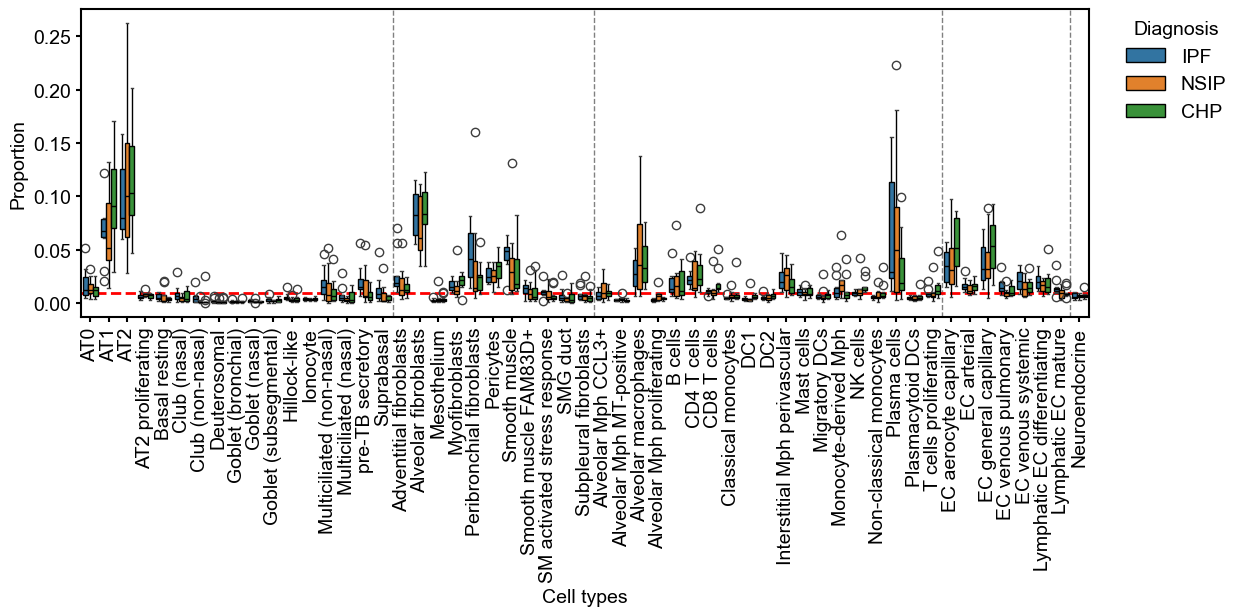

In [34]:
plt.figure(figsize = (13,4))
sns.boxplot(data=df_norm_cat_melt[df_norm_cat_melt["cond"]!="UNC"], x= "Cell types", y= "Normalized count", hue = "cond", hue_order=["IPF","NSIP","CHP"],order  = cell_type_order_full,
            boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops)
plt.xticks(rotation=90)

# Add vertical lines between groups
for idx in group_full_split_indices:
    plt.axvline(x=idx - 0.5, color='gray', linestyle='--', linewidth=1, zorder=0)

plt.axhline(y=0.01, c = 'red', ls = "--", zorder = 0, lw = 2)
plt.xlabel("Cell types")
plt.ylabel("Proportion")
plt.legend(title = "Diagnosis", loc = 'center left', bbox_to_anchor = (1.02, 0.8), frameon=False)
plt.savefig(os.path.join(save_dir, "normalized_count.png"), transparent=True, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, "normalized_count.svg"), transparent=True, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, "normalized_count.pdf"), transparent=True, bbox_inches='tight')

In [35]:
group_dict = {
    "Epithelial" : ["AT0", "AT1", "AT2", "Multiciliated (non-nasal)", "pre-TB secretory"],
    "Stroma" : ["Adventitial fibroblasts","Alveolar fibroblasts", "Myofibroblasts", "Peribronchial fibroblasts", "Pericytes",
                "Smooth muscle", "Smooth muscle FAM83D+", "Subpleural fibroblasts"],
    "Immune" : ["Alveolar Mph CCL3+","Alveolar macrophages", "B cells", "CD4 T cells",
                "CD8 T cells", "Interstitial Mph perivascular", "Mast cells", "Monocyte-derived Mph", "NK cells", "Plasma cells", "T cells proliferating"],
    "Endothelial" : ["EC aerocyte capillary", "EC arterial", "EC general capillary", "EC venous pulmonary", 
                     "EC venous systemic", "Lymphatic EC differentiating", "Lymphatic EC mature"]

}

In [36]:
cell_type_order = [celltype for group in group_dict.values() for celltype in group]
cell_type_order

['AT0',
 'AT1',
 'AT2',
 'Multiciliated (non-nasal)',
 'pre-TB secretory',
 'Adventitial fibroblasts',
 'Alveolar fibroblasts',
 'Myofibroblasts',
 'Peribronchial fibroblasts',
 'Pericytes',
 'Smooth muscle',
 'Smooth muscle FAM83D+',
 'Subpleural fibroblasts',
 'Alveolar Mph CCL3+',
 'Alveolar macrophages',
 'B cells',
 'CD4 T cells',
 'CD8 T cells',
 'Interstitial Mph perivascular',
 'Mast cells',
 'Monocyte-derived Mph',
 'NK cells',
 'Plasma cells',
 'T cells proliferating',
 'EC aerocyte capillary',
 'EC arterial',
 'EC general capillary',
 'EC venous pulmonary',
 'EC venous systemic',
 'Lymphatic EC differentiating',
 'Lymphatic EC mature']

In [37]:
# Compute index positions where each group ends
group_lengths = [len(group) for group in group_dict.values()]
group_split_indices = np.cumsum(group_lengths)[:-1] 

In [38]:
group_split_indices

array([ 5, 13, 24])

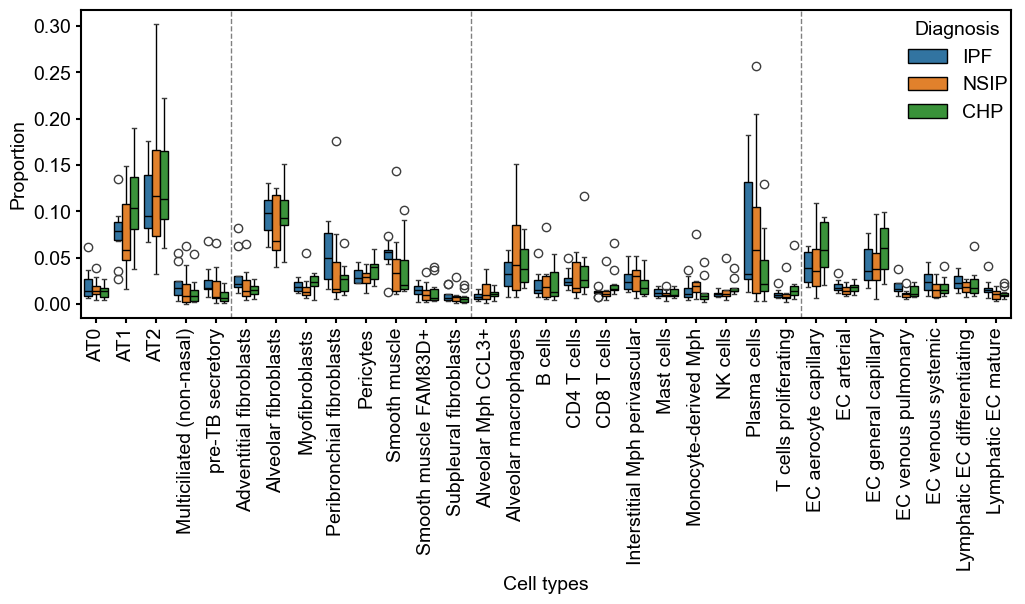

In [89]:
plt.figure(figsize = (12,4))
sns.boxplot(data=df_norm_filtered_cat_melt[df_norm_filtered_cat_melt["cond"]!="UNC"], x= "Cell types", y= "Normalized count", hue = "cond", hue_order=["IPF","NSIP","CHP"],
            order  = cell_type_order,
            boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops)
plt.xticks(rotation=90)
#plt.axhline(y=0.01, c = 'red', ls = "--", zorder = 0, lw = 2)

# Add vertical lines between groups
for idx in group_split_indices:
    plt.axvline(x=idx - 0.5, color='gray', linestyle='--', linewidth=1, zorder=0)


plt.xlabel("Cell types")
plt.ylabel("Proportion")
plt.legend(title = "Diagnosis", loc = 'center left', bbox_to_anchor = (0.87, 0.8), frameon=False)
plt.savefig(os.path.join(save_dir, "normalized_filtered_count.png"), transparent=True, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, "normalized_filtered_count.svg"), transparent=True, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, "normalized_filtered_count.pdf"), transparent=True, bbox_inches='tight')

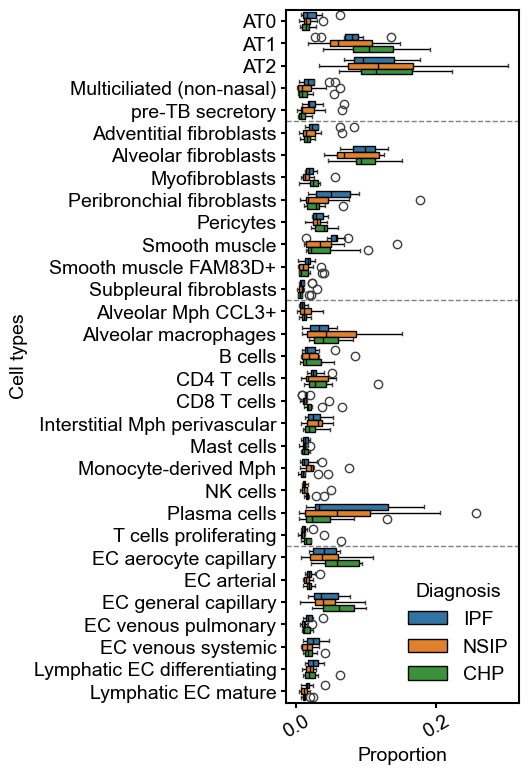

In [42]:
plt.figure(figsize = (3,9))
sns.boxplot(data=df_norm_filtered_cat_melt[df_norm_filtered_cat_melt["cond"]!="UNC"], y= "Cell types", x= "Normalized count", hue = "cond", hue_order=["IPF","NSIP","CHP"],
            order  = cell_type_order,
            boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops)
plt.xticks(rotation=90)
#plt.axhline(y=0.01, c = 'red', ls = "--", zorder = 0, lw = 2)

# Add vertical lines between groups
for idx in group_split_indices:
    plt.axhline(y=idx - 0.5, color='gray', linestyle='--', linewidth=1, zorder=0)


plt.ylabel("Cell types")
plt.xlabel("Proportion")
plt.xticks(rotation = 30)
plt.legend(title = "Diagnosis", loc = 'center left', bbox_to_anchor = (0.45, 0.1), frameon=False)
plt.savefig(os.path.join(save_dir, "normalized_filtered_count_rot.png"), transparent=True, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, "normalized_filtered_count_rot.svg"), transparent=True, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, "normalized_filtered_count_rot.pdf"), transparent=True, bbox_inches='tight')

In [44]:
df_norm_filtered_cat[df_norm_filtered_cat['cond']=="IPF"].T.loc[reversed(cell_type_order),:].to_excel(os.path.join(save_dir, "prop_IPF_filtered_cell_type_ordered.xlsx"))
df_norm_filtered_cat[df_norm_filtered_cat['cond']=="NSIP"].T.loc[reversed(cell_type_order),:].to_excel(os.path.join(save_dir, "prop_NSIP_filtered_cell_type_ordered.xlsx"))
df_norm_filtered_cat[df_norm_filtered_cat['cond']=="CHP"].T.loc[reversed(cell_type_order),:].to_excel(os.path.join(save_dir, "prop_CHP_filtered_cell_type_ordered.xlsx"))

In [45]:
print(sns.color_palette("deep").as_hex())

['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860', '#da8bc3', '#8c8c8c', '#ccb974', '#64b5cd']


In [46]:
# Step 1: Group and sum
grouped = df[df['cond']!="UNC"].groupby('library_id')[['AT2', 'AT1']].sum()

# Step 2: Compute ratio and assign a label
grouped['ratio'] = grouped['AT2'] / grouped['AT1']

# Step 3: Keep only the ratio column (optional) and reset index
ratio = grouped[['ratio']]

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_1361/1740607736.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df[df['cond']!="UNC"].groupby('library_id')[['AT2', 'AT1']].sum()


In [47]:
ratio

,ratio
library_id,
06_30914_A1,1.330002
08_38774_B2,1.510580
11_13888_A1,0.904895
12_39986_A2,NaN
16_39724_B1,1.534437
16_46257_A1,NaN
16_53837_A10,NaN
17_25789_B1,1.108468
17_35291_B1,NaN


In [48]:
ratio_cat = pd.concat([cond, ratio], axis =1)

In [49]:
ratio_cat

,cond,ratio
library_id,,
06_30914_A1,NSIP,1.330002
08_38774_B2,CHP,1.510580
11_13888_A1,CHP,0.904895
12_39986_A2,UNC,NaN
16_39724_B1,CHP,1.534437
16_46257_A1,UNC,NaN
16_53837_A10,UNC,NaN
17_25789_B1,CHP,1.108468
17_35291_B1,UNC,NaN


In [50]:
boxprops=dict(edgecolor="black")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='black')
flierprops = dict(marker='x', markerfacecolor='lightgrey', markersize=1,
                  linestyle='none')

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_1361/448904323.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


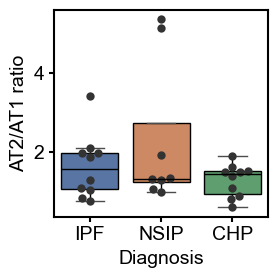

In [52]:
# Define the order you want
cond_order = ['IPF', 'NSIP', 'CHP']

# Use seaborn's 'deep' palette and select 3 colors
palette = sns.color_palette('deep', n_colors=3)


plt.figure(figsize=(3, 3))

# Create the boxplot
sns.boxplot(
    data=ratio_cat,
    x='cond',
    y='ratio',
    order=cond_order,
    palette=palette,
    flierprops=flierprops, boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops
)


# Scatter / strip plot (individual points)
sns.swarmplot(
    data=ratio_cat,
    x='cond',
    y='ratio',
    order=cond_order,
    color=".2",          # dark gray points
    size=6,
    zorder=2             # make sure points appear above the box
)


# Optional styling
plt.title('')
plt.xlabel('Diagnosis')
plt.ylabel('AT2/AT1 ratio')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "AT2_AT1_ratio.pdf"), transparent=True, bbox_inches='tight')
plt.show()

In [99]:
# Save abs cell counts of filtered ct list

In [100]:
adata_vis.obs[ list(cts_nmf_filtered)].to_excel(os.path.join(save_dir,"ann_finest_level_abs_cell_count.xlsx"))